# Multi-Class Classification  7-Class Attack Classification

In this notebook, I implement an optimized pipeline for classifying 7 different attack types from the CICIoT2023 dataset.

This is the Reviewer 3 working copy. It keeps the same simple structure as the original notebook, but it adds stricter data loading, fixed feature order, fairer tuning controls, cleaner threshold tuning, and saved artifacts for the hierarchical pipeline.

### Pipeline Overview
1. **Data Loading and Preparation**: Loading the parquet files and cleaning missing/infinite values.
2. **Filtering and Encoding**: Isolating attack traffic and mapping labels to 0-6.
3. **Robust Scaling**: Utilizing RobustScaler to better handle extreme outliers common in network traffic.
4. **Feature Selection**: Training RF and ExtraTrees to extract the Top 30 most impactful features.
5. **Custom Sample Weights**: Applying a 1.5x boost to minority classes to force the models to learn their patterns.
6. **Baselines**: Establishing starting metrics using Decision Tree, XGBoost, and Random Forest.
7. **Hyperparameter Tuning**: Using Optuna to tune Decision Tree, XGBoost, and Random Forest under the same trial budget.
8. **Ensembling**: Combining predictions via Voting and Stacking strategies.
9. **Threshold Tuning**: Searching per-class probability thresholds on a held-out training validation split only.
10. **Final Evaluation**: Comparing all approaches and saving the best model and hierarchy handoff files.



---
## Step 0: Install Dependencies

Before starting, I ensure my environment has all the necessary packages for data manipulation, visualization, and advanced machine learning models (like XGBoost and Optuna for tuning).



In [1]:
# Install required Python packages for data processing and machine learning.

%pip install pandas numpy scikit-learn xgboost optuna matplotlib seaborn pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 1: Setup & Imports & Data Loading

load core libraries and prepare the dataset.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
import json
from pathlib import Path
from collections import Counter

from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, f1_score, accuracy_score,
                             precision_score)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')

RANDOM_STATE = 42
N_TRIALS = 40
TOP_N = 30
BOOST_FACTOR = 1.5
XGB_DEVICE = os.environ.get('XGB_DEVICE', 'cuda')

np.random.seed(RANDOM_STATE)

NOTEBOOK_DIR = Path.cwd().resolve()
processed_candidates = []
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    processed_candidates.append(parent / 'output' / 'processed')
    processed_candidates.append(parent / 'Hierarchical-IoT-Intrusion-Detection' / 'output' / 'processed')
processed_candidates.append((NOTEBOOK_DIR / '..' / 'output' / 'processed').resolve())

processed_dir = None
for candidate in processed_candidates:
    candidate = candidate.resolve()
    if (candidate / 'X_train.parquet').exists() and (candidate / 'feature_columns.json').exists():
        processed_dir = candidate
        break

if processed_dir is None:
    checked = '\n'.join(str(p.resolve()) for p in processed_candidates)
    raise FileNotFoundError('Could not find output/processed. Run the EDA feature engineering notebook first.\n' + checked)

PROJECT_ROOT = processed_dir.parent.parent
results_dir = PROJECT_ROOT / 'results' / 'reviewer3_multiclass'
models_dir = PROJECT_ROOT / 'models' / 'reviewer3_multiclass'
tuning_logs_dir = results_dir / 'tuning_logs'

results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
tuning_logs_dir.mkdir(parents=True, exist_ok=True)

print('All libraries loaded.')
print('Processed data:', processed_dir)
print('Results dir:', results_dir)
print('Models dir:', models_dir)
print('Optuna trials per tuned model:', N_TRIALS)
print('XGBoost device:', XGB_DEVICE)


All libraries loaded.
Processed data: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\output\processed
Results dir: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_multiclass
Models dir: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\models\reviewer3_multiclass
Optuna trials per tuned model: 40
XGBoost device: cuda


### 1.1 - Load Preprocessed Data


In [3]:
t0 = time.time()

X_train = pd.read_parquet(processed_dir / 'X_train.parquet')
X_test  = pd.read_parquet(processed_dir / 'X_test.parquet')
y_train_all = pd.read_parquet(processed_dir / 'y_train.parquet')
y_test_all  = pd.read_parquet(processed_dir / 'y_test.parquet')

with open(processed_dir / 'feature_columns.json', 'r', encoding='utf-8') as f:
    feature_columns = json.load(f)

with open(processed_dir / 'preprocessing_config.json', 'r', encoding='utf-8') as f:
    preprocessing_config = json.load(f)

with open(processed_dir / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

le_8 = label_encoders['le_8']
le_34 = label_encoders['le_34']

assert list(X_train.columns) == feature_columns, 'X_train feature order does not match feature_columns.json'
assert list(X_test.columns) == feature_columns, 'X_test feature order does not match feature_columns.json'
assert X_train.shape[1] == preprocessing_config['expected_feature_count'], 'Unexpected train feature count'
assert X_test.shape[1] == preprocessing_config['expected_feature_count'], 'Unexpected test feature count'
assert len(X_train) == len(y_train_all), 'Train feature/target row count mismatch'
assert len(X_test) == len(y_test_all), 'Test feature/target row count mismatch'

print(f'Data loaded in {time.time()-t0:.1f}s')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')
print('Feature order locked from feature_columns.json')


Data loaded in 6.2s
X_train: (5599989, 40)  |  X_test: (1399998, 40)
Features: 40
Feature order locked from feature_columns.json


### 1.2 - Data Cleaning and Preparation


In [4]:
# Check for missing (NaN) values in the dataset and fill them using the median strategy.

train_miss = X_train.isnull().sum().sum()
test_miss = X_test.isnull().sum().sum()
print(f'Missing: train={train_miss}, test={test_miss}')
if train_miss > 0 or test_miss > 0:
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)
    print('  -> Filled with median')

Missing: train=0, test=0


In [5]:
# Check for infinite values in the dataset. Replace them with NaN, then fill with the median.

train_inf = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
test_inf = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()
print(f'Infinite: train={train_inf}, test={test_inf}')
if train_inf > 0 or test_inf > 0:
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan)
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)
    print('  -> Replaced inf with median')

Infinite: train=0, test=0


---
## Step 2: Filter Benign and Re-encode Labels

filtering out the benign traffic here so the models can focus exclusively on distinguishing between the 7 different attack classes. I also remap the labels to a clean 0-6 range for algorithmic computation.



In [6]:
# Filter out benign traffic to focus exclusively on classifying the 7 distinct attack types.

benign_id = int(le_8.transform(['Benign'])[0])
y_train_8 = y_train_all['class_8']
y_test_8  = y_test_all['class_8']

train_atk_mask = y_train_8 != benign_id
test_atk_mask  = y_test_8 != benign_id

train_attack_index = X_train.index[train_atk_mask].to_numpy()
test_attack_index = X_test.index[test_atk_mask].to_numpy()

print(f'Benign class id from encoder: {benign_id}')
print(f'Train: {train_atk_mask.sum()} attacks, {(~train_atk_mask).sum()} benign')
print(f'Test : {test_atk_mask.sum()} attacks, {(~test_atk_mask).sum()} benign')

X_train_atk = X_train.loc[train_atk_mask].reset_index(drop=True)
X_test_atk  = X_test.loc[test_atk_mask].reset_index(drop=True)
y_train_atk = y_train_8.loc[train_atk_mask].reset_index(drop=True)
y_test_atk  = y_test_8.loc[test_atk_mask].reset_index(drop=True)

assert y_train_atk.nunique() == 7, 'Training attack set must contain 7 attack families'
assert y_test_atk.nunique() == 7, 'Test attack set must contain 7 attack families'


Benign class id from encoder: 0
Train: 4721433 attacks, 878556 benign
Test : 1180359 attacks, 219639 benign


In [7]:
# Encode the original attack-family ids into a clean integer range from 0 to 6.

orig_classes = sorted(y_train_atk.unique().tolist())
label_map = {old: new for new, old in enumerate(orig_classes)}
reverse_map = {v: k for k, v in label_map.items()}
attack_names = le_8.inverse_transform(orig_classes).tolist()
minority_attack_names = ['BruteForce', 'Web']
minority_classes = [attack_names.index(name) for name in minority_attack_names if name in attack_names]

y_train_enc = y_train_atk.map(label_map)
y_test_enc  = y_test_atk.map(label_map)
num_classes = len(orig_classes)

assert num_classes == 7, f'Expected 7 attack classes, got {num_classes}'
assert y_train_enc.isna().sum() == 0, 'Unmapped train labels found'
assert y_test_enc.isna().sum() == 0, 'Unmapped test labels found'

print(f'\n{num_classes} attack classes:')
dist = y_train_enc.value_counts().sort_index()
for c in range(num_classes):
    pct = dist.get(c, 0) / len(y_train_enc) * 100
    marker = ' ** MINORITY **' if c in minority_classes else ''
    print(f'  Class {c} ({attack_names[c]:12s}): {dist.get(c,0):>10,} ({pct:5.2f}%){marker}')



7 attack classes:
  Class 0 (BruteForce  ):     10,391 ( 0.22%) ** MINORITY **
  Class 1 (DDoS        ):  3,239,833 (68.62%)
  Class 2 (DoS         ):    764,781 (16.20%)
  Class 3 (Mirai       ):    232,811 ( 4.93%)
  Class 4 (Recon       ):    283,614 ( 6.01%)
  Class 5 (Spoofing    ):    170,125 ( 3.60%)
  Class 6 (Web         ):     19,878 ( 0.42%) ** MINORITY **


---
## Step 3: RobustScaler

I chose `RobustScaler` instead of `StandardScaler` because network traffic data naturally contains extreme outliers. By relying on the median and interquartile range (IQR), this scaling method prevents those outliers from distorting the feature distributions.



In [8]:
# Apply RobustScaler to the features, which utilizes IQR to mitigate the effect of large network traffic outliers.

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_atk),
    columns=X_train_atk.columns,
    index=X_train_atk.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_atk),
    columns=X_test_atk.columns,
    index=X_test_atk.index
)
print(f'RobustScaler applied. Shape: {X_train_scaled.shape}')

RobustScaler applied. Shape: (4721433, 40)


---
## Step 4: Feature Selection (RF + ExtraTrees)

To reduce dimensionality and eliminate noise, I train both Random Forest and ExtraTrees classifiers to rank feature importance. I average their scores to securely select the Top 30 most robust features.



In [9]:
# Train a Random Forest and an ExtraTrees classifier to compute and average feature importances.

print('Training RF for feature importances.')
t0 = time.time()
rf_fs = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_fs.fit(X_train_scaled, y_train_enc)
rf_importances = pd.Series(rf_fs.feature_importances_, index=X_train_scaled.columns)
print(f'  RF done in {time.time()-t0:.1f}s')

print('Training ExtraTrees for feature importances.')
t0 = time.time()
et_fs = ExtraTreesClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
et_fs.fit(X_train_scaled, y_train_enc)
et_importances = pd.Series(et_fs.feature_importances_, index=X_train_scaled.columns)
print(f'  ET done in {time.time()-t0:.1f}s')

# Average importances from both models
avg_importances = (rf_importances + et_importances) / 2
avg_importances = avg_importances.sort_values(ascending=False)


Training RF for feature importances.
  RF done in 164.6s
Training ExtraTrees for feature importances.
  ET done in 233.9s


In [10]:
# Identify the top features based on the combined average importance scores.

top_features = avg_importances.head(TOP_N).index.tolist()

print(f'\nTop {TOP_N} features (RF+ET average):')
for i, feat in enumerate(top_features, 1):
    print(f'  {i:2d}. {feat:30s}  importance={avg_importances[feat]:.4f}')



Top 30 features (RF+ET average):
   1. IAT                             importance=0.2252
   2. Variance                        importance=0.0630
   3. Protocol Type                   importance=0.0560
   4. AVG                             importance=0.0467
   5. Header_Length                   importance=0.0443
   6. Tot size                        importance=0.0437
   7. bytes_per_packet                importance=0.0424
   8. Min                             importance=0.0422
   9. Tot sum                         importance=0.0405
  10. header_payload_ratio            importance=0.0335
  11. Max                             importance=0.0329
  12. flow_duration                   importance=0.0323
  13. flag_density                    importance=0.0299
  14. syn_count                       importance=0.0277
  15. urg_count                       importance=0.0255
  16. Duration                        importance=0.0254
  17. Std                             importance=0.0237
  18. Rate    

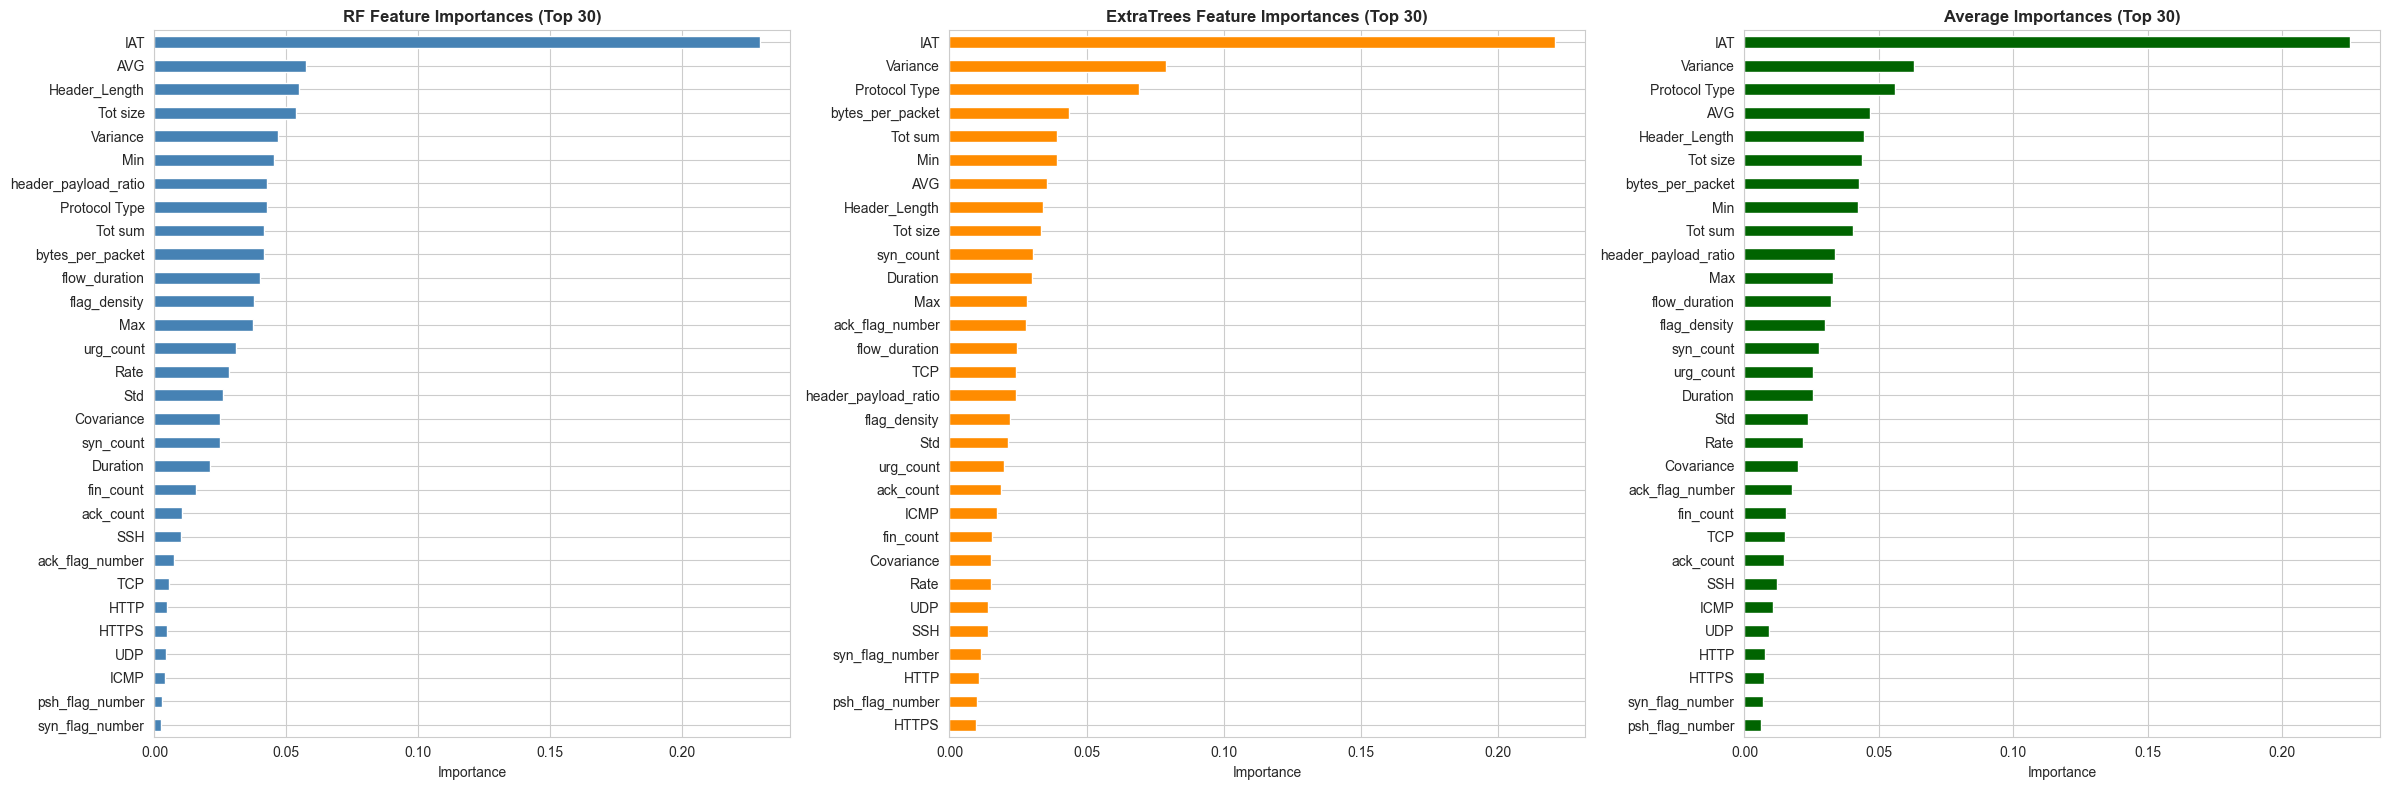

In [11]:
# Visualize the top feature importances from RF, ET, and their averaged combination.

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

rf_importances.sort_values(ascending=True).tail(TOP_N).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title(f'RF Feature Importances (Top {TOP_N})', fontweight='bold')
axes[0].set_xlabel('Importance')

et_importances.sort_values(ascending=True).tail(TOP_N).plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title(f'ExtraTrees Feature Importances (Top {TOP_N})', fontweight='bold')
axes[1].set_xlabel('Importance')

avg_importances.sort_values(ascending=True).tail(TOP_N).plot.barh(ax=axes[2], color='darkgreen')
axes[2].set_title(f'Average Importances (Top {TOP_N})', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [12]:
# Subset the original training and testing datasets to retain only the top selected features.

X_train_sel = X_train_scaled[top_features]
X_test_sel  = X_test_scaled[top_features]
print(f'Selected features: {X_train_sel.shape[1]} (from {X_train_scaled.shape[1]})')

X_train_tree = X_train_atk[top_features].reset_index(drop=True)
X_test_tree  = X_test_atk[top_features].reset_index(drop=True)

Selected features: 30 (from 40)


---
## Step 5: Compute Boosted Sample Weights

Classes 0 (BruteForce) and 6 (Web) are extreme minorities in this dataset. To prevent the models from ignoring them, I generate balanced sample weights and then apply an additional 1.5x multiplier specifically to these rare classes.



In [13]:
# Calculate boosted custom sample weights to penalize mistakes on rare attack types.

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = dict(zip(np.unique(y_train_enc), class_weights_arr))

base_sw = compute_sample_weight('balanced', y_train_enc)
sample_weights = base_sw.copy()
for cls in minority_classes:
    sample_weights[y_train_enc == cls] *= BOOST_FACTOR

class_counts = Counter(y_train_enc)
n_total = len(y_train_enc)
custom_cw = {}
for cls in range(num_classes):
    w = n_total / (num_classes * class_counts[cls])
    if cls in minority_classes:
        w *= BOOST_FACTOR
    custom_cw[cls] = float(w)

print(f'Boost factor: {BOOST_FACTOR}x for minority classes {minority_attack_names}')
print(f'Weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]')
print('\nClass weights (boosted):')
for c in range(num_classes):
    boost = ' << BOOSTED' if c in minority_classes else ''
    print(f'  Class {c} ({attack_names[c]:12s}): {custom_cw[c]:.2f}{boost}')

results = {}
predictions = {}
classification_reports = {}


Boost factor: 1.5x for minority classes ['BruteForce', 'Web']
Weight range: [0.2082, 97.3665]

Class weights (boosted):
  Class 0 (BruteForce  ): 97.37 << BOOSTED
  Class 1 (DDoS        ): 0.21
  Class 2 (DoS         ): 0.88
  Class 3 (Mirai       ): 2.90
  Class 4 (Recon       ): 2.38
  Class 5 (Spoofing    ): 3.96
  Class 6 (Web         ): 50.90 << BOOSTED


---
## Step 6: Functions

To keep  code clean and avoid repetition, I define a standardized evaluation function here. It automatically calculates macro/weighted F1, Precision, and Recall, plots a confusion matrix, and stores the results for final comparison.



### 6.1 - Evaluate Model

In [14]:
# Define a comprehensive evaluation function to calculate metrics, print reports, and plot confusion matrices.

def evaluate(name, y_true, y_pred, train_time):
    """Evaluate a model, print metrics, plot confusion matrix, store results."""
    y_pred = np.asarray(y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro')
    f1m = f1_score(y_true, y_pred, average='macro')
    f1w = f1_score(y_true, y_pred, average='weighted')
    pcr = recall_score(y_true, y_pred, average=None, zero_division=0)

    results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'time': train_time,
        'min_class_recall': float(np.min(pcr)),
        'minority_recall_mean': float(np.mean([pcr[c] for c in minority_classes])) if minority_classes else np.nan,
    }
    predictions[name] = y_pred
    classification_reports[name] = classification_report(
        y_true, y_pred, target_names=attack_names, output_dict=True, zero_division=0
    )

    print(f'\n--- {name} ---')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  Precision(M): {prec:.4f}')
    print(f'  Recall(M):    {rec:.4f}')
    print(f'  F1(macro):    {f1m:.4f}')
    print(f'  F1(weighted): {f1w:.4f}')
    print(f'  Time:         {train_time:.1f}s')

    for c in range(len(pcr)):
        m = ' ** MINORITY' if c in minority_classes else ''
        print(f'    Class {c} ({attack_names[c]:12s}) recall: {pcr[c]:.4f}{m}')

    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
                xticklabels=attack_names, yticklabels=attack_names,
                annot_kws={'size': 8}, linewidths=0.5)
    axes[0].set_title(f'{name} -- Counts', fontweight='bold')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
                xticklabels=attack_names, yticklabels=attack_names,
                annot_kws={'size': 8}, linewidths=0.5)
    axes[1].set_title(f'{name} -- Percentage (%)', fontweight='bold')
    axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=attack_names, zero_division=0))
    return acc, rec, f1m


### 6.2 - Process and Save Tuning Logs


In [15]:
# Define a universal log processing function to aggregate JSON trial performance for any Optuna model search.

def process_and_save_logs(model_name, trial_prefix, output_filename):
    log_files = [f for f in os.listdir(tuning_logs_dir) if f.startswith(trial_prefix) and f.endswith('.json')]

    def get_trial_num(filename):
        return int(filename.split('_')[-1].split('.')[0])

    log_files.sort(key=get_trial_num)
    print(f"Processing {model_name} logs...")

    with open(output_filename, 'w', encoding='utf-8') as out_file:
        header_text = f"ALL RECONSTRUCTED GLOBAL REPORTS FOR {model_name.upper()}\n\n"
        print(header_text)
        out_file.write(header_text)

        for filename in log_files:
            trial_num = get_trial_num(filename)
            filepath = tuning_logs_dir / filename

            with open(filepath, 'r', encoding='utf-8') as file:
                data = json.load(file)

            trial_header = f"{'='*50}\n {model_name.upper()} TRIAL {trial_num} | Target Score: {data['score']:.4f}\n{'='*50}\n"
            print(trial_header, end='')
            out_file.write(trial_header)

            reports = data['reports']
            classes = [k for k in reports[0].keys() if isinstance(reports[0][k], dict) and k not in ['macro avg', 'weighted avg']]

            global_report = {}
            for c in classes:
                total_tp = 0
                total_fp = 0
                total_support = 0

                for rep in reports:
                    r = rep[c]
                    support = r['support']
                    recall = r['recall']
                    precision = r['precision']

                    tp = recall * support
                    fp = (tp / precision - tp) if precision > 0 else 0

                    total_tp += tp
                    total_fp += fp
                    total_support += support

                glob_prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
                glob_rec = total_tp / total_support if total_support > 0 else 0
                glob_f1 = 2 * (glob_prec * glob_rec) / (glob_prec + glob_rec) if (glob_prec + glob_rec) > 0 else 0

                global_report[c] = {
                    'precision': glob_prec,
                    'recall': glob_rec,
                    'f1-score': glob_f1,
                    'support': int(total_support)
                }

            df_report = pd.DataFrame(global_report).transpose()
            report_str = df_report[['precision', 'recall', 'f1-score', 'support']].round(4).to_string()

            print(report_str + "\n\n")
            out_file.write(report_str + "\n\n\n")

    print(f"Execution complete. You can also find the full output saved in '{output_filename}'")


---
## Step 7: Baseline Models

Before doing any complex tuning, I establish a baseline using standard Decision Trees, XGBoost, and Random Forest. This gives me a clear reference point to measure exactly how much my later hyperparameter tuning actually improves the model.




--- Decision Tree Baseline ---

--- Decision Tree Baseline ---
  Accuracy:     0.9886
  Precision(M): 0.8764
  Recall(M):    0.8764
  F1(macro):    0.8764
  F1(weighted): 0.9886
  Time:         55.9s
    Class 0 (BruteForce  ) recall: 0.6850 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9999
    Class 2 (DoS         ) recall: 0.9995
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.9223
    Class 5 (Spoofing    ) recall: 0.8798
    Class 6 (Web         ) recall: 0.6488 ** MINORITY


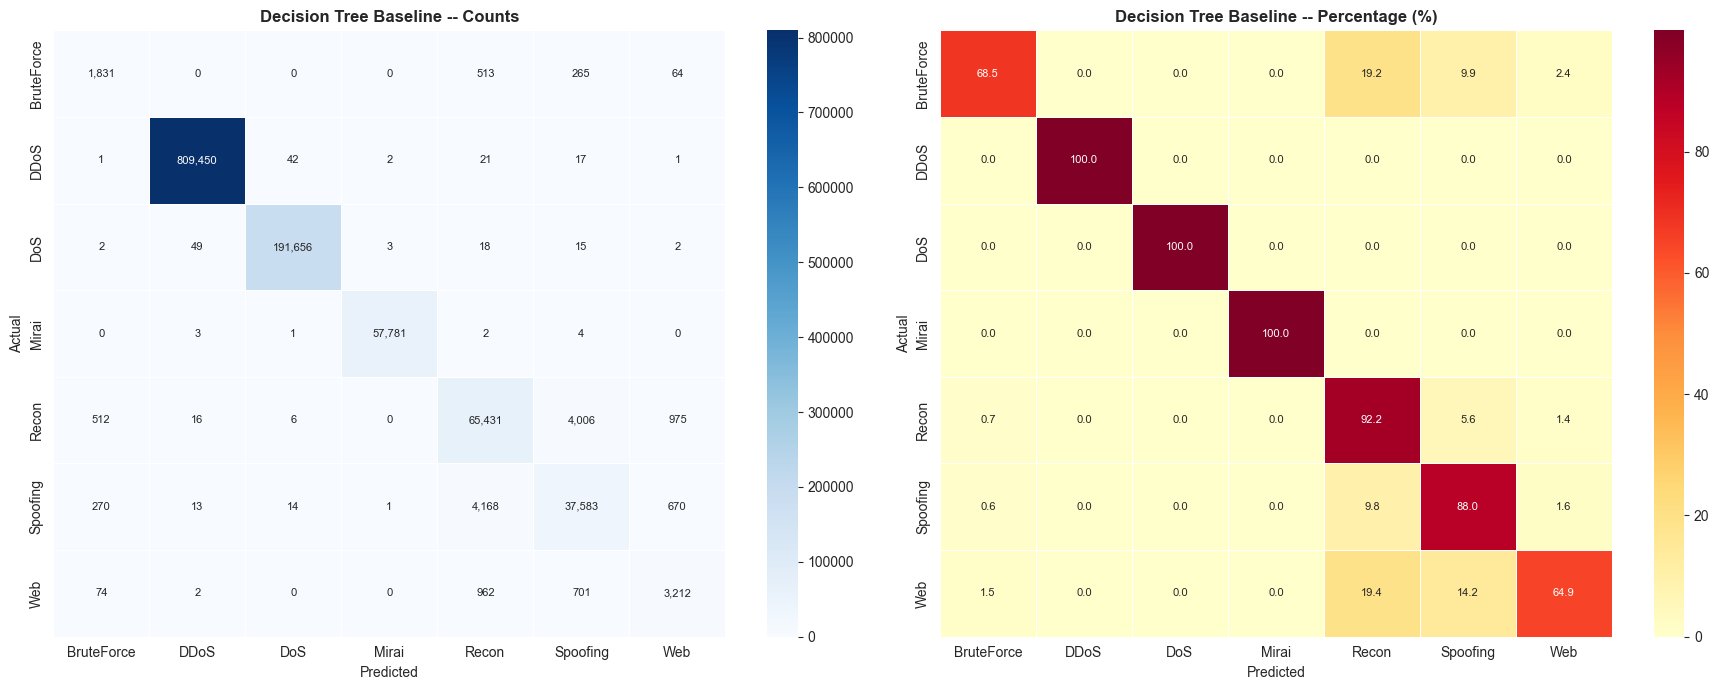

              precision    recall  f1-score   support

  BruteForce       0.68      0.68      0.68      2673
        DDoS       1.00      1.00      1.00    809534
         DoS       1.00      1.00      1.00    191745
       Mirai       1.00      1.00      1.00     57791
       Recon       0.92      0.92      0.92     70946
    Spoofing       0.88      0.88      0.88     42719
         Web       0.65      0.65      0.65      4951

    accuracy                           0.99   1180359
   macro avg       0.88      0.88      0.88   1180359
weighted avg       0.99      0.99      0.99   1180359



(0.988634813645679, 0.8764360407156081, 0.8764258011668117)

In [16]:
# Train and evaluate a baseline Decision Tree model using standard balanced weights.

from sklearn.tree import DecisionTreeClassifier
print('\n--- Decision Tree Baseline ---')
t0 = time.time()
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_base.fit(X_train_tree, y_train_enc)
dt_time = time.time() - t0
y_pred_dt = dt_base.predict(X_test_tree)
evaluate('Decision Tree Baseline', y_test_enc, y_pred_dt, dt_time)

### 7.2 - XGBoost Baseline


Training XGBoost (baseline) with boosted sample weights...

--- XGB Baseline ---
  Accuracy:     0.9837
  Precision(M): 0.7883
  Recall(M):    0.9230
  F1(macro):    0.8125
  F1(weighted): 0.9865
  Time:         8.0s
    Class 0 (BruteForce  ) recall: 0.8706 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9995
    Class 2 (DoS         ) recall: 0.9997
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.8364
    Class 5 (Spoofing    ) recall: 0.8495
    Class 6 (Web         ) recall: 0.9053 ** MINORITY


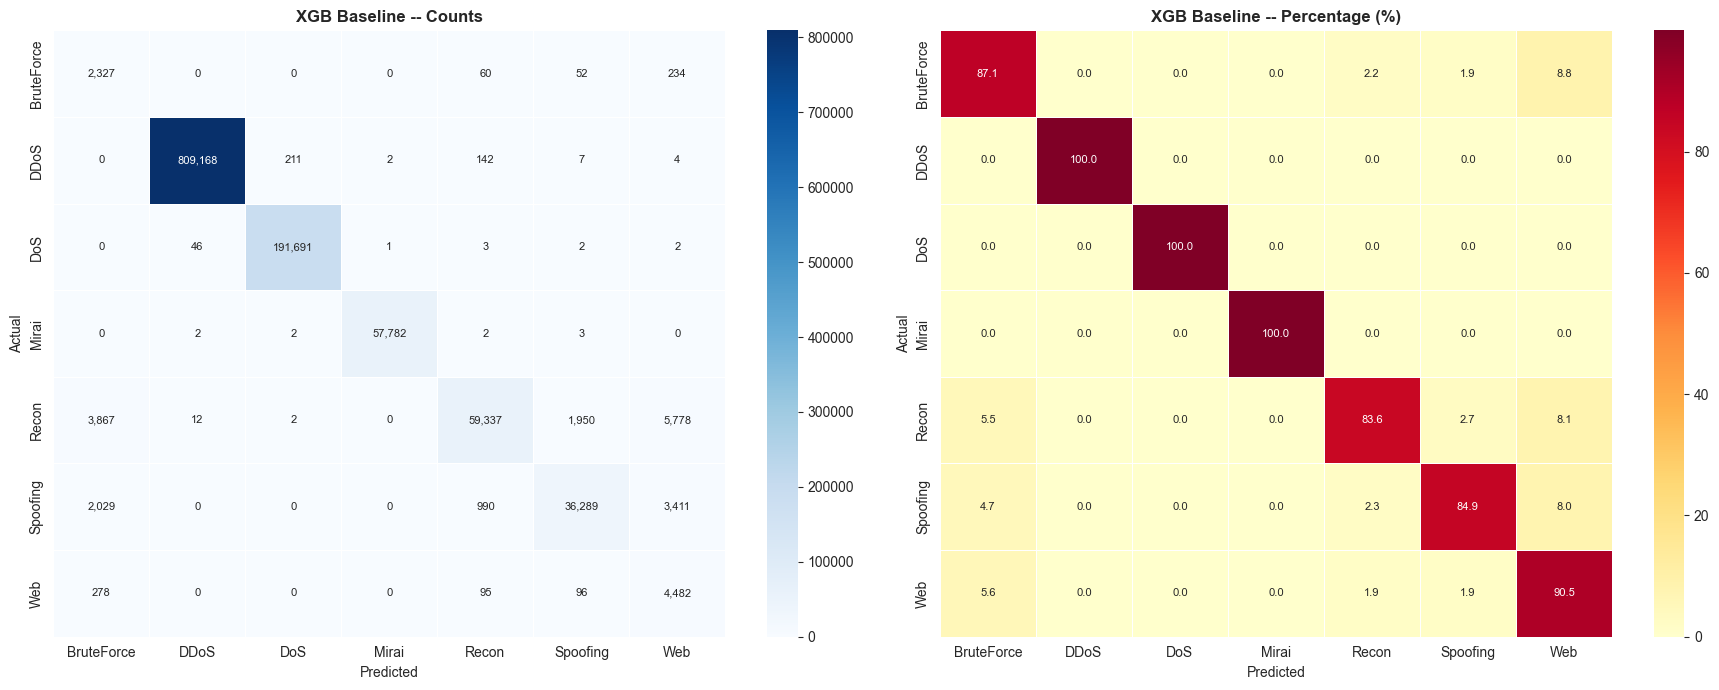

              precision    recall  f1-score   support

  BruteForce       0.27      0.87      0.42      2673
        DDoS       1.00      1.00      1.00    809534
         DoS       1.00      1.00      1.00    191745
       Mirai       1.00      1.00      1.00     57791
       Recon       0.98      0.84      0.90     70946
    Spoofing       0.95      0.85      0.89     42719
         Web       0.32      0.91      0.48      4951

    accuracy                           0.98   1180359
   macro avg       0.79      0.92      0.81   1180359
weighted avg       0.99      0.98      0.99   1180359



(0.9836634447655332, 0.9229699456859084, 0.8124780571210098)

In [41]:
# Train and evaluate a baseline XGBoost model utilizing the custom boosted sample weights.

print('Training XGBoost (baseline) with boosted sample weights...')
t0 = time.time()
xgb_base = XGBClassifier(reg_alpha=0.3, reg_lambda=0.6, device='cuda', tree_method='hist', random_state=42)
xgb_base.fit(X_train_tree, y_train_enc, sample_weight=sample_weights)
xgb_time = time.time() - t0
y_pred_xgb = xgb_base.predict(X_test_tree)
evaluate('XGB Baseline', y_test_enc, y_pred_xgb, xgb_time)


### 7.4 - Baseline Comparison


Baseline Models Comparison:


,Accuracy,Precision(M),Recall(M),F1(macro),F1(weighted),Time(s)
Decision Tree Baseline,0.988635,0.876420,0.876436,0.876426,0.988632,55.920108
XGB Baseline,0.983663,0.788345,0.922970,0.812478,0.986474,7.969902


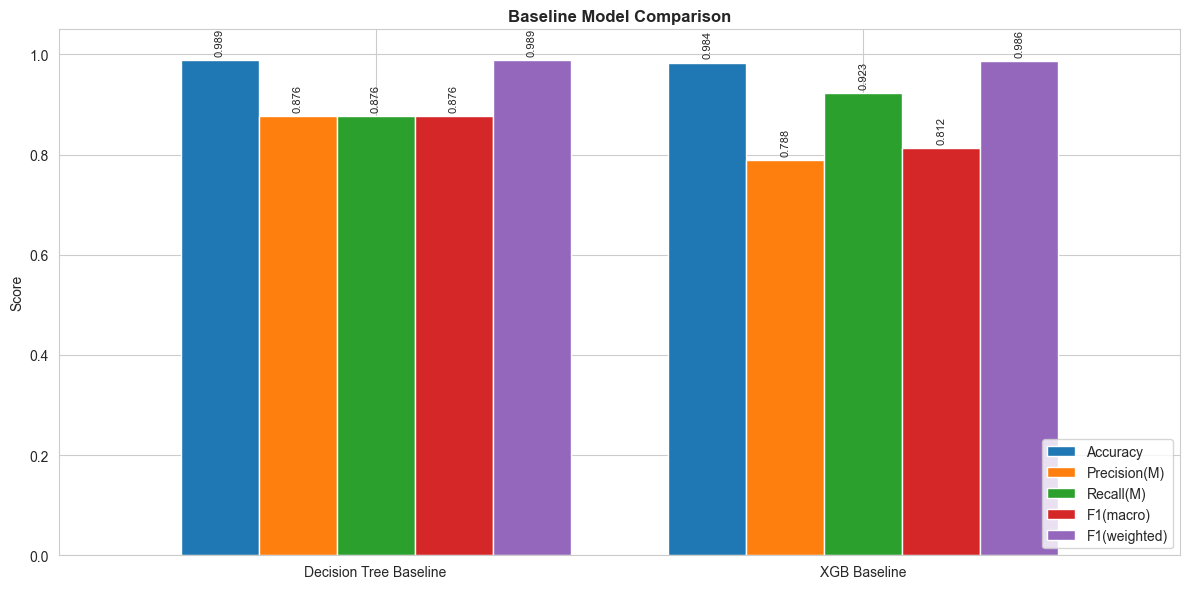

In [43]:
# Compare only the baseline models that are actually used in this notebook section.

baseline_model_names = [
    'Decision Tree Baseline',
    'XGB Baseline'
]

baseline_model_names = [name for name in baseline_model_names if name in results]

assert len(baseline_model_names) > 0, 'No baseline results found. Run the baseline model cells first.'

baseline_df = pd.DataFrame({name: results[name] for name in baseline_model_names}).T

baseline_df = baseline_df[['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted', 'time']]
baseline_df.columns = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)', 'Time(s)']

print('Baseline Models Comparison:')
display(baseline_df)

plot_cols = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)']

ax = baseline_df[plot_cols].plot(kind='bar', figsize=(12, 6), width=0.8)
ax.set_title('Baseline Model Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, rotation=90, padding=3)

plt.tight_layout()
plt.show()

---
## Step 8: Optuna Hyperparameter Tuning

utilize Optuna to systematically search for the best hyperparameters for Decision Tree, XGBoost, and Random Forest. The objective function is customized to maximize Macro F1 and Precision/Recall, with extra attention to minority attack classes.



In [20]:
# Set up Stratified K-Fold cross-validation and directory structure for structured Optuna hyperparameter tuning.

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
print('CV folds:', cv.get_n_splits())
print('Tuning logs:', tuning_logs_dir)


CV folds: 3
Tuning logs: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_multiclass\tuning_logs


### 8.0 - Tune Decision Tree

This keeps the Decision Tree baseline fair. It gets the same Optuna trial budget as XGBoost and Random Forest, using the same selected features and cross-validation split.


  0%|          | 0/40 [00:00<?, ?it/s]

Best DT score: 0.8638
Best params: {'class_weight_type': 'custom', 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 3, 'criterion': 'entropy', 'max_features': None}

--- DT Tuned ---
  Accuracy:     0.9864
  Precision(M): 0.8085
  Recall(M):    0.8953
  F1(macro):    0.8364
  F1(weighted): 0.9874
  Time:         48.5s
    Class 0 (BruteForce  ) recall: 0.7501 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9999
    Class 2 (DoS         ) recall: 0.9998
    Class 3 (Mirai       ) recall: 0.9999
    Class 4 (Recon       ) recall: 0.8794
    Class 5 (Spoofing    ) recall: 0.8695
    Class 6 (Web         ) recall: 0.7689 ** MINORITY


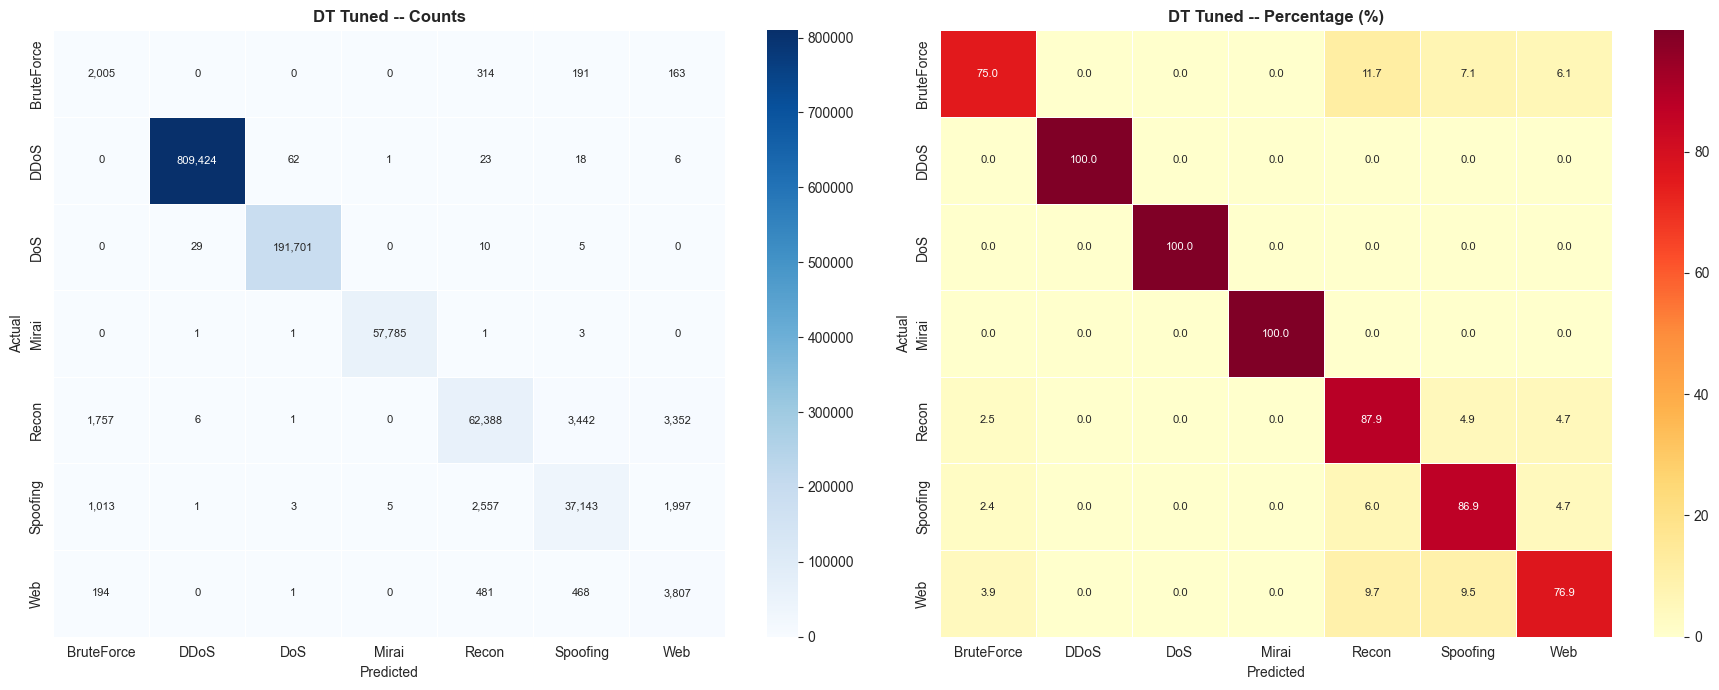

              precision    recall  f1-score   support

  BruteForce       0.40      0.75      0.52      2673
        DDoS       1.00      1.00      1.00    809534
         DoS       1.00      1.00      1.00    191745
       Mirai       1.00      1.00      1.00     57791
       Recon       0.95      0.88      0.91     70946
    Spoofing       0.90      0.87      0.88     42719
         Web       0.41      0.77      0.53      4951

    accuracy                           0.99   1180359
   macro avg       0.81      0.90      0.84   1180359
weighted avg       0.99      0.99      0.99   1180359



(0.9863549987757961, 0.8953436523248876, 0.8363856713931244)

In [21]:
# Tune Decision Tree with the same Optuna budget.

def dt_objective(trial):
    cw_choice = trial.suggest_categorical('class_weight_type', ['balanced', 'custom'])
    cw_val = 'balanced' if cw_choice == 'balanced' else custom_cw

    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 100),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'class_weight': cw_val,
        'random_state': RANDOM_STATE,
    }

    scores = []
    trial_reports = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_tree, y_train_enc)):
        model = DecisionTreeClassifier(**params)
        model.fit(X_train_tree.iloc[train_idx], y_train_enc.iloc[train_idx])
        y_pred = model.predict(X_train_tree.iloc[val_idx])

        macro_f1 = f1_score(y_train_enc.iloc[val_idx], y_pred, average='macro')
        macro_rec = recall_score(y_train_enc.iloc[val_idx], y_pred, average='macro')
        combined_score = (0.5 * macro_f1) + (0.5 * macro_rec)

        scores.append(combined_score)
        rep = classification_report(y_train_enc.iloc[val_idx], y_pred, output_dict=True, zero_division=0)
        trial_reports.append(rep)

    avg_score = float(np.mean(scores))

    safe_params = params.copy()
    if isinstance(safe_params.get('class_weight'), dict):
        safe_params['class_weight'] = {str(k): float(v) for k, v in safe_params['class_weight'].items()}

    with open(tuning_logs_dir / f'dt_trial_{trial.number}.json', 'w', encoding='utf-8') as f:
        json.dump({'params': safe_params, 'score': avg_score, 'reports': trial_reports}, f, indent=2)

    return avg_score

study_dt = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_dt.optimize(dt_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Best DT score: {study_dt.best_value:.4f}')
print(f'Best params: {study_dt.best_params}')

best_dt_p = study_dt.best_params.copy()
cw_final_dt = 'balanced' if best_dt_p.pop('class_weight_type') == 'balanced' else custom_cw
best_dt_p.update({'class_weight': cw_final_dt, 'random_state': RANDOM_STATE})

t0 = time.time()
dt_tuned = DecisionTreeClassifier(**best_dt_p)
dt_tuned.fit(X_train_tree, y_train_enc)
dt_t_time = time.time() - t0
y_pred_dt_t = dt_tuned.predict(X_test_tree)
evaluate('DT Tuned', y_test_enc, y_pred_dt_t, dt_t_time)


### 8.1 - XGBoost Objective Function

In [22]:
# Define the Optuna objective function for XGBoost using Softprob and Stratified Fold cross-validation.

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'eval_metric': 'mlogloss',
        'device': XGB_DEVICE,
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
    }

    scores = []
    trial_reports = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_tree, y_train_enc)):
        model = XGBClassifier(**params)
        sw_fold = sample_weights[train_idx]

        model.fit(X_train_tree.iloc[train_idx], y_train_enc.iloc[train_idx],
                  sample_weight=sw_fold)

        y_pred = model.predict(X_train_tree.iloc[val_idx])

        macro_f1 = f1_score(y_train_enc.iloc[val_idx], y_pred, average='macro')
        macro_prec = precision_score(y_train_enc.iloc[val_idx], y_pred, average='macro', zero_division=0)
        combined_score = (0.5 * macro_f1) + (0.5 * macro_prec)

        scores.append(combined_score)

        rep = classification_report(y_train_enc.iloc[val_idx], y_pred, output_dict=True, zero_division=0)
        trial_reports.append(rep)

    avg_score = float(np.mean(scores))

    with open(tuning_logs_dir / f'xgb_trial_{trial.number}.json', 'w', encoding='utf-8') as f:
        json.dump({'params': params, 'score': avg_score, 'reports': trial_reports}, f, indent=2)

    return avg_score


### 8.2 - Tune XGBoost

  0%|          | 0/40 [00:00<?, ?it/s]


Best XGBoost score: 0.9272
Best params: {'n_estimators': 771, 'max_depth': 14, 'learning_rate': 0.0851448021913703, 'subsample': 0.766460303200905, 'colsample_bytree': 0.5660646605067485, 'colsample_bylevel': 0.9171322991487559, 'min_child_weight': 1, 'gamma': 0.010298078420679868, 'reg_alpha': 0.016821345303315537, 'reg_lambda': 1.7840079042385777}

--- XGB Tuned ---
  Accuracy:     0.9919
  Precision(M): 0.9453
  Recall(M):    0.8881
  F1(macro):    0.9126
  F1(weighted): 0.9918
  Time:         137.4s
    Class 0 (BruteForce  ) recall: 0.6839 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9997
    Class 2 (DoS         ) recall: 0.9997
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.9580
    Class 5 (Spoofing    ) recall: 0.9131
    Class 6 (Web         ) recall: 0.6627 ** MINORITY


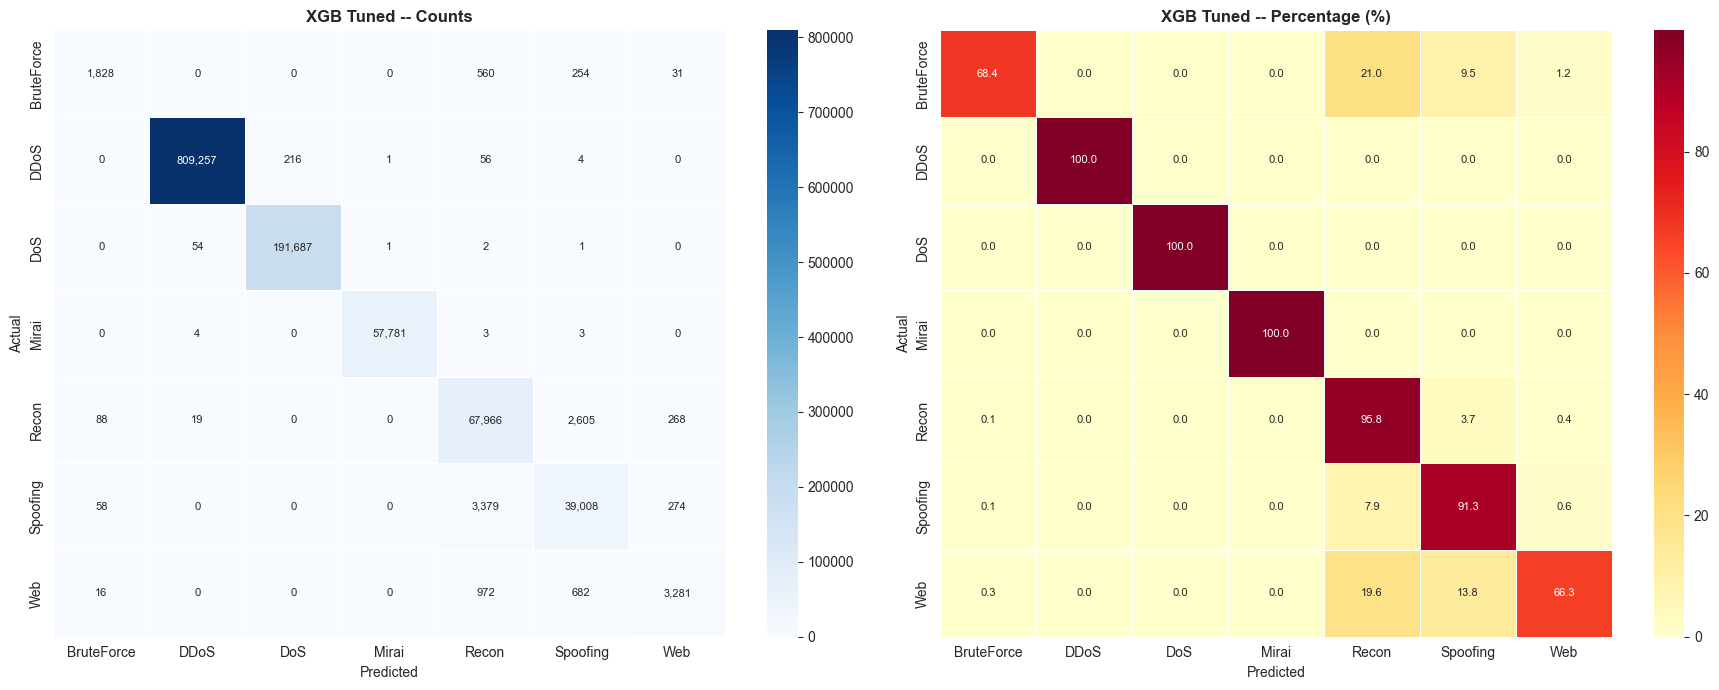

              precision    recall  f1-score   support

  BruteForce       0.92      0.68      0.78      2673
        DDoS       1.00      1.00      1.00    809534
         DoS       1.00      1.00      1.00    191745
       Mirai       1.00      1.00      1.00     57791
       Recon       0.93      0.96      0.94     70946
    Spoofing       0.92      0.91      0.91     42719
         Web       0.85      0.66      0.75      4951

    accuracy                           0.99   1180359
   macro avg       0.95      0.89      0.91   1180359
weighted avg       0.99      0.99      0.99   1180359



(0.9919083939716645, 0.8881255310108289, 0.9125520310289463)

In [23]:
# Create the Optuna study and execute the optimization process for XGBoost to find the best macro F1.

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest XGBoost score: {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

best_xgb_p = study_xgb.best_params.copy()
best_xgb_p.update({
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'eval_metric': 'mlogloss',
    'device': XGB_DEVICE,
    'tree_method': 'hist',
    'random_state': RANDOM_STATE,
})

t0 = time.time()
xgb_tuned = XGBClassifier(**best_xgb_p)
xgb_tuned.fit(X_train_tree, y_train_enc, sample_weight=sample_weights)
xgb_t_time = time.time() - t0

y_pred_xgb_t = xgb_tuned.predict(X_test_tree)
evaluate('XGB Tuned', y_test_enc, y_pred_xgb_t, xgb_t_time)


### 8.3 - Evaluate Best Minority XGB Trial

In [24]:
# Read through the saved Optuna JSON logs to find the single trial that maximized precision for the minority classes.

best_minority_score = -1
best_minority_params = None
best_trial_name = ''

for filename in os.listdir(tuning_logs_dir):
    if filename.startswith('xgb_trial_') and filename.endswith('.json'):
        filepath = tuning_logs_dir / filename

        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        reports = data['reports']
        minority_precision = []
        for cls in minority_classes:
            minority_precision.append(np.mean([rep.get(str(cls), {}).get('precision', 0) for rep in reports]))
        combined_minority_prec = float(np.mean(minority_precision)) if minority_precision else 0

        if combined_minority_prec > best_minority_score:
            best_minority_score = combined_minority_prec
            best_minority_params = data['params']
            best_trial_name = filename

print(f'Best Trial for minority classes: {best_trial_name}')
print(f'Average minority precision: {best_minority_score:.4f}')
print('Best Minority Parameters:')
for k, v in best_minority_params.items():
    print(f'  {k}: {v}')


Best Trial for minority classes: xgb_trial_22.json
Average minority precision: 0.8831
Best Minority Parameters:
  n_estimators: 771
  max_depth: 14
  learning_rate: 0.0851448021913703
  subsample: 0.766460303200905
  colsample_bytree: 0.5660646605067485
  colsample_bylevel: 0.9171322991487559
  min_child_weight: 1
  gamma: 0.010298078420679868
  reg_alpha: 0.016821345303315537
  reg_lambda: 1.7840079042385777
  objective: multi:softprob
  num_class: 7
  eval_metric: mlogloss
  device: cuda
  tree_method: hist
  random_state: 42


### 8.4 - Process and Save XGB Tuning Logs


In [25]:
# Aggregate trial reports from the Decision Tree and XGBoost searches.
process_and_save_logs('Decision Tree', 'dt_trial_', results_dir / 'ALL_DT_TRIALS_REPORTS.txt')
process_and_save_logs('XGBoost', 'xgb_trial_', results_dir / 'ALL_XGB_TRIALS_REPORTS.txt')


Processing Decision Tree logs...
ALL RECONSTRUCTED GLOBAL REPORTS FOR DECISION TREE


 DECISION TREE TRIAL 0 | Target Score: 0.8515
   precision  recall  f1-score    support
0     0.2639  0.7878    0.3953    10391.0
1     1.0000  0.9997    0.9998  3239833.0
2     0.9995  0.9997    0.9996   764781.0
3     0.9994  0.9999    0.9996   232811.0
4     0.9660  0.8365    0.8966   283614.0
5     0.9141  0.8452    0.8783   170125.0
6     0.3219  0.8210    0.4625    19878.0


 DECISION TREE TRIAL 1 | Target Score: 0.8607
   precision  recall  f1-score    support
0     0.3583  0.7541    0.4858    10391.0
1     1.0000  0.9997    0.9999  3239833.0
2     0.9994  0.9997    0.9995   764781.0
3     0.9995  0.9998    0.9997   232811.0
4     0.9532  0.8662    0.9076   283614.0
5     0.8903  0.8652    0.8776   170125.0
6     0.3903  0.7760    0.5194    19878.0


 DECISION TREE TRIAL 2 | Target Score: 0.7733
   precision  recall  f1-score    support
0     0.0956  0.7968    0.1707    10391.0
1     0.9997  0.

### 8.9 - Tuned vs Baselines Comparison


Models Comparison:


,Accuracy,Precision(M),Recall(M),F1(macro),F1(weighted),Time(s)
XGB Tuned,0.991908,0.945300,0.888126,0.912552,0.991768,137.387048
Decision Tree Baseline,0.988635,0.876420,0.876436,0.876426,0.988632,55.920108
DT Tuned,0.986355,0.808539,0.895344,0.836386,0.987420,48.465402
XGB Baseline,0.983663,0.788345,0.922970,0.812478,0.986474,7.969902


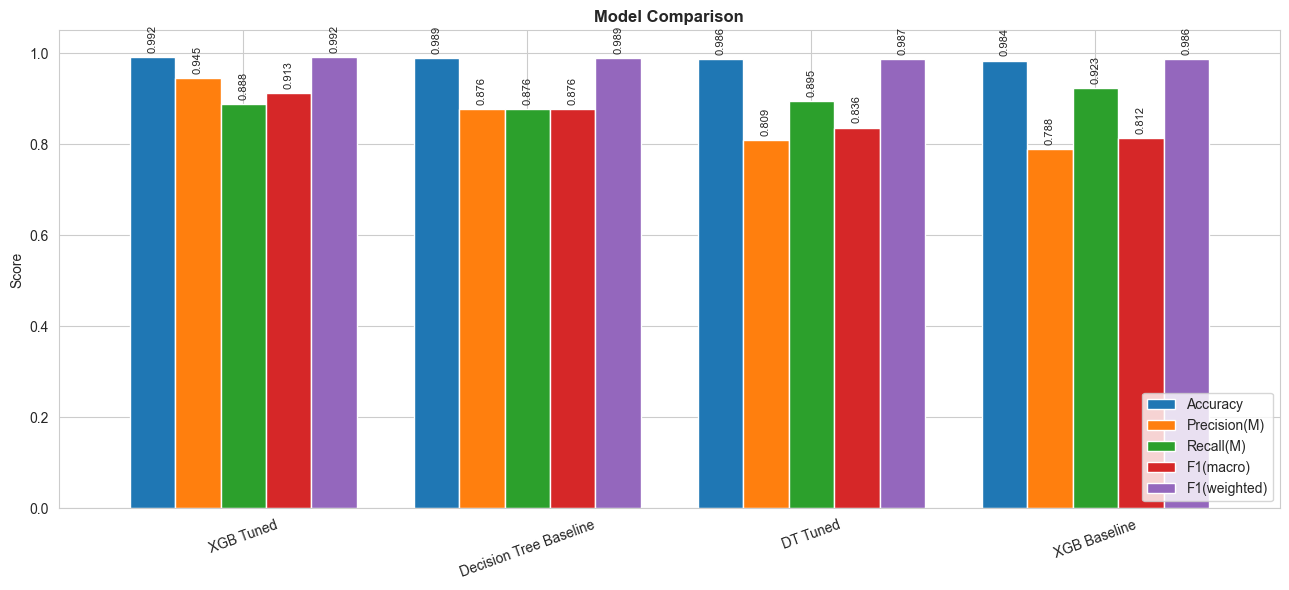

In [45]:
# Compare only the tuned/baseline models that are actually available.

comparison_model_names = [
    'Decision Tree Baseline',
    'XGB Baseline',
    'DT Tuned',
    'XGB Tuned'
]

comparison_model_names = [name for name in comparison_model_names if name in results]

assert len(comparison_model_names) > 0, 'No model results found. Run the model cells first.'

all_df = pd.DataFrame({name: results[name] for name in comparison_model_names}).T

all_df = all_df[['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted', 'time']]
all_df.columns = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)', 'Time(s)']

print('Models Comparison:')
display(all_df.sort_values('F1(macro)', ascending=False))

plot_cols = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)']

ax = all_df[plot_cols].sort_values('F1(macro)', ascending=False).plot(
    kind='bar',
    figsize=(13, 6),
    width=0.8
)

ax.set_title('Model Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, rotation=90, padding=3)

plt.tight_layout()
plt.show()

---
## Step 9: Ensemble Models

Even with heavily tuned models, individual algorithms have blind spots. Here, I combine the strengths of both XGBoost and Random Forest using two strategies:
1. **Voting (Soft)**: Averages their predicted probabilities.
2. **Stacking**: Uses a Logistic Regression meta-model to learn *when* to trust XGBoost vs Random Forest.



Training Voting Ensemble (soft)...

--- Voting Ensemble ---
  Accuracy:     0.9875
  Precision(M): 0.8123
  Recall(M):    0.8995
  F1(macro):    0.8398
  F1(weighted): 0.9885
  Time:         204.5s
    Class 0 (BruteForce  ) recall: 0.7643 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9999
    Class 2 (DoS         ) recall: 0.9998
    Class 3 (Mirai       ) recall: 0.9999
    Class 4 (Recon       ) recall: 0.8972
    Class 5 (Spoofing    ) recall: 0.8698
    Class 6 (Web         ) recall: 0.7655 ** MINORITY


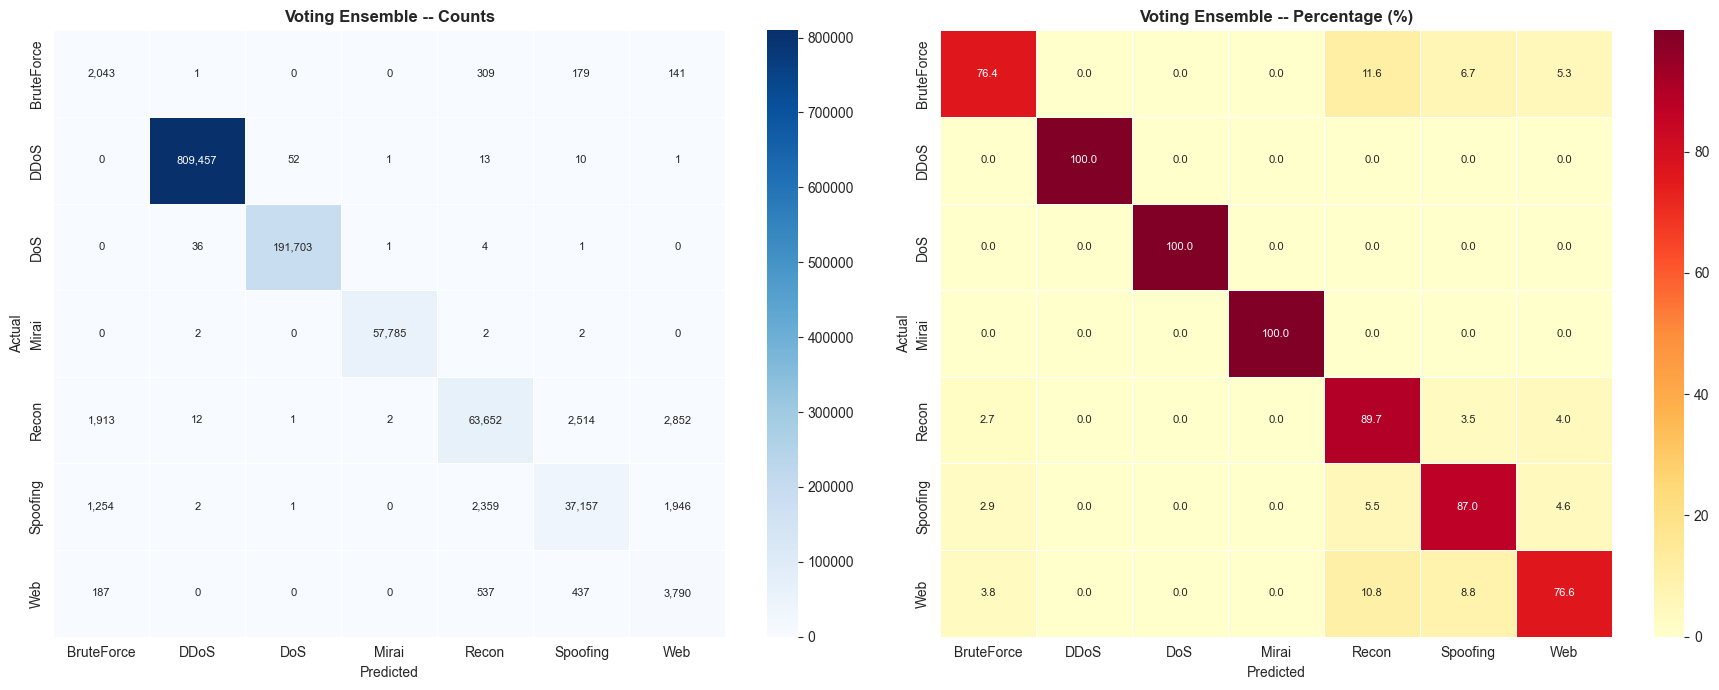

              precision    recall  f1-score   support

  BruteForce       0.38      0.76      0.51      2673
        DDoS       1.00      1.00      1.00    809534
         DoS       1.00      1.00      1.00    191745
       Mirai       1.00      1.00      1.00     57791
       Recon       0.95      0.90      0.92     70946
    Spoofing       0.92      0.87      0.90     42719
         Web       0.43      0.77      0.55      4951

    accuracy                           0.99   1180359
   macro avg       0.81      0.90      0.84   1180359
weighted avg       0.99      0.99      0.99   1180359



(0.9874851634121483, 0.8994833482946588, 0.839826326734015)

In [31]:
# Train a soft-voting ensemble model combining the predictions of the tuned XGBoost and RF classifiers.

print('Training Voting Ensemble (soft)...')
t0 = time.time()
voting = VotingClassifier(
    estimators=[('xgb', xgb_tuned), ('dt', dt_tuned)],
    voting='soft'
)
voting.fit(X_train_tree, y_train_enc, sample_weight=sample_weights)
voting_time = time.time() - t0
y_pred_vote = voting.predict(X_test_tree)
evaluate('Voting Ensemble', y_test_enc, y_pred_vote, voting_time)

---
## Step 10: Per-Class Threshold Tuning

Traditional `argmax` probability assignment hurts our rare classes. Instead, I computationally search for optimal threshold multipliers. By amplifying the predicted probabilities for BruteForce and Web, I encourage the model to confidently predict them when it sees subtle patterns.



### 10.1 - Find Best Thresholds

In [32]:
# Create a held-out validation set from training data for threshold tuning.
# The threshold model is trained only on X_train_thresh, so X_val_thresh is not seen by that model.

X_train_thresh, X_val_thresh, y_train_thresh, y_val_thresh = train_test_split(
    X_train_tree, y_train_enc,
    test_size=0.2,
    stratify=y_train_enc,
    random_state=RANDOM_STATE
)

sw_train_thresh = sample_weights[X_train_thresh.index]
print(f'Threshold-tuning split: train={len(X_train_thresh)}, val={len(X_val_thresh)}')


Threshold-tuning split: train=3777146, val=944287


In [33]:
# Extract predicted probabilities on the VALIDATION set and search for best thresholds.
# A separate XGBoost model is trained without the validation rows to keep threshold tuning clean.

print('Training a clean XGBoost copy for threshold tuning...')
xgb_threshold_model = XGBClassifier(**best_xgb_p)
xgb_threshold_model.fit(X_train_thresh, y_train_thresh, sample_weight=sw_train_thresh)

print('Extracting probabilities for threshold tuning on VALIDATION set...')
y_proba_val = xgb_threshold_model.predict_proba(X_val_thresh)

best_thresh = np.ones(num_classes)
best_f1 = 0

thresh_vals = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

print('Searching threshold multipliers for minority classes...')
for t0_v in thresh_vals:
    for t1_v in thresh_vals:
        th = np.ones(num_classes)
        if len(minority_classes) >= 1:
            th[minority_classes[0]] = t0_v
        if len(minority_classes) >= 2:
            th[minority_classes[1]] = t1_v

        adj = y_proba_val * th
        pred = np.argmax(adj, axis=1)

        mf1 = f1_score(y_val_thresh, pred, average='macro')

        if mf1 > best_f1:
            best_f1 = mf1
            best_thresh = th.copy()

print(f'\nBest thresholds (tuned on validation set): {best_thresh}')
print(f'Best macro F1 on validation set: {best_f1:.4f}')


Training a clean XGBoost copy for threshold tuning...
Extracting probabilities for threshold tuning on VALIDATION set...
Searching threshold multipliers for minority classes...

Best thresholds (tuned on validation set): [1.5 1.  1.  1.  1.  1.  0.7]
Best macro F1 on validation set: 0.9159


### 10.2 - Apply Thresholds & Evaluate


--- XGB Threshold-Tuned ---
  Accuracy:     0.9919
  Precision(M): 0.9456
  Recall(M):    0.8882
  F1(macro):    0.9126
  F1(weighted): 0.9918
  Time:         137.4s
    Class 0 (BruteForce  ) recall: 0.6985 ** MINORITY
    Class 1 (DDoS        ) recall: 0.9997
    Class 2 (DoS         ) recall: 0.9997
    Class 3 (Mirai       ) recall: 0.9998
    Class 4 (Recon       ) recall: 0.9584
    Class 5 (Spoofing    ) recall: 0.9137
    Class 6 (Web         ) recall: 0.6477 ** MINORITY


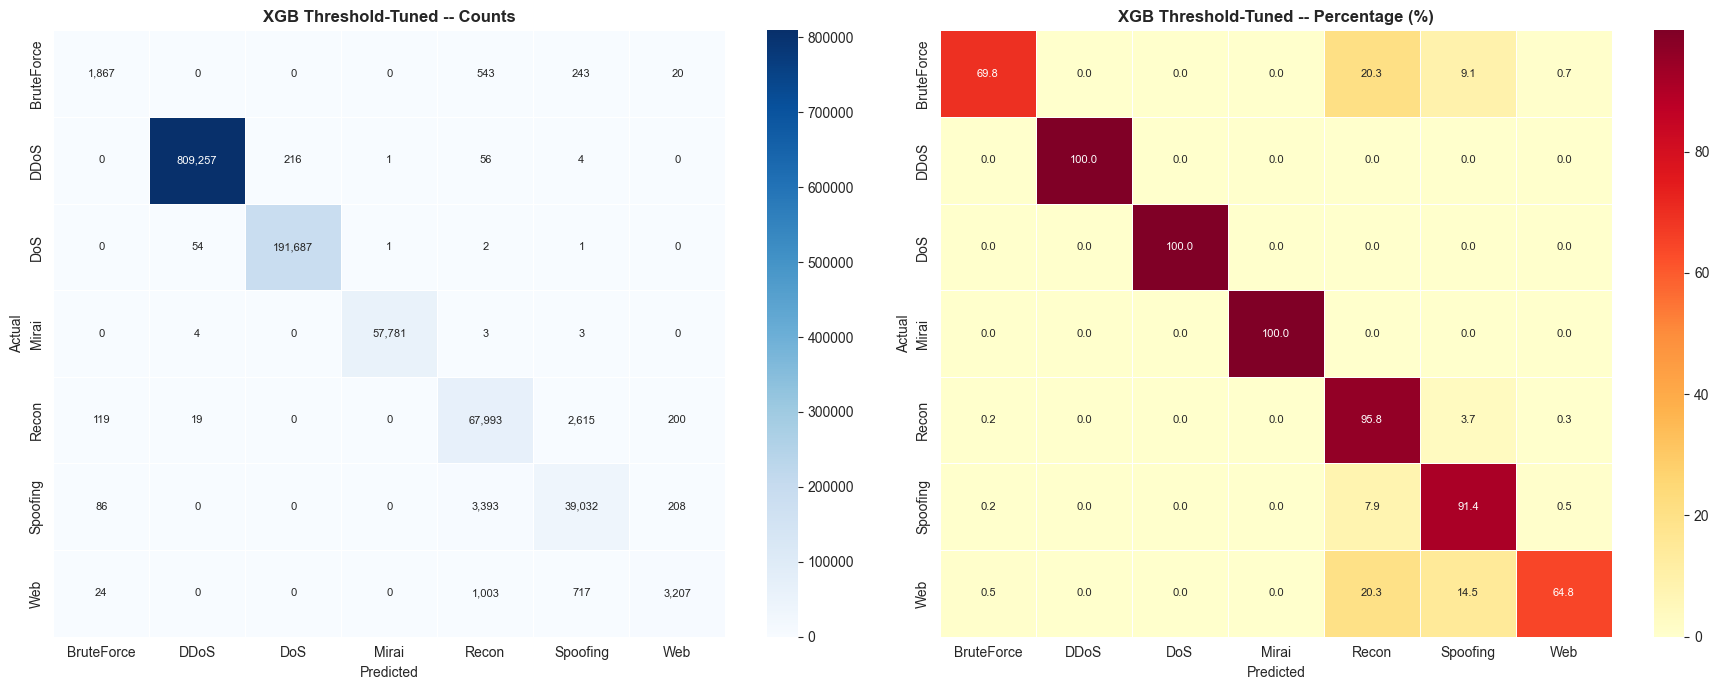

              precision    recall  f1-score   support

  BruteForce       0.89      0.70      0.78      2673
        DDoS       1.00      1.00      1.00    809534
         DoS       1.00      1.00      1.00    191745
       Mirai       1.00      1.00      1.00     57791
       Recon       0.93      0.96      0.94     70946
    Spoofing       0.92      0.91      0.91     42719
         Web       0.88      0.65      0.75      4951

    accuracy                           0.99   1180359
   macro avg       0.95      0.89      0.91   1180359
weighted avg       0.99      0.99      0.99   1180359



(0.9919219491697018, 0.8882092816546295, 0.912645643166118)

In [34]:
# Apply the chosen threshold multipliers to the UNTOUCHED TEST SET and evaluate.
# The final XGB model is trained on the full training attack set, while thresholds came from train-only validation.

y_proba_test = xgb_tuned.predict_proba(X_test_tree)
adj_proba = y_proba_test * best_thresh
y_pred_thresh = np.argmax(adj_proba, axis=1)

evaluate('XGB Threshold-Tuned', y_test_enc, y_pred_thresh, xgb_t_time)


In [35]:
# Compare the per-class recall scores before and after applying the tuned decision thresholds.

print('Per-class Recall: XGB Tuned vs Threshold-Tuned')
rec_b = recall_score(y_test_enc, y_pred_xgb_t, average=None, zero_division=0)
rec_a = recall_score(y_test_enc, y_pred_thresh, average=None, zero_division=0)
for c in range(num_classes):
    d = rec_a[c] - rec_b[c]
    arrow = '+' if d > 0 else ''
    m = ' << IMPROVED' if d > 0.01 else ''
    print(f'  Class {c} ({attack_names[c]:12s}): {rec_b[c]:.4f} -> {rec_a[c]:.4f} ({arrow}{d:.4f}){m}')


Per-class Recall: XGB Tuned vs Threshold-Tuned
  Class 0 (BruteForce  ): 0.6839 -> 0.6985 (+0.0146) << IMPROVED
  Class 1 (DDoS        ): 0.9997 -> 0.9997 (0.0000)
  Class 2 (DoS         ): 0.9997 -> 0.9997 (0.0000)
  Class 3 (Mirai       ): 0.9998 -> 0.9998 (0.0000)
  Class 4 (Recon       ): 0.9580 -> 0.9584 (+0.0004)
  Class 5 (Spoofing    ): 0.9131 -> 0.9137 (+0.0006)
  Class 6 (Web         ): 0.6627 -> 0.6477 (-0.0149)


---
## Step 11: Final Comparison and  Save

In this final step, I compile all the metrics from the baselines, the tuned models, and the ensembles into a single DataFrame. I sort them by Macro F1 to objectively identify the absolute best performing model, which I then serialize (pickle) along with its label encoders for future deployment.



In [46]:
# Build the final results DataFrame using only the models kept in this notebook.

final_model_names = [
    'Decision Tree Baseline',
    'XGB Baseline',
    'DT Tuned',
    'XGB Tuned',
    'XGB Threshold-Tuned'
]

# Keep only models that actually ran and exist in results
final_model_names = [name for name in final_model_names if name in results]

assert len(final_model_names) > 0, 'No model results found. Run the model cells first.'

final_df = pd.DataFrame({name: results[name] for name in final_model_names}).T

final_df = final_df[['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted',
                     'min_class_recall', 'minority_recall_mean', 'time']]

final_df.columns = ['Accuracy', 'Precision(M)', 'Recall(M)', 'F1(macro)', 'F1(weighted)',
                    'Min Recall', 'Minority Recall Mean', 'Time(s)']

final_df = final_df.sort_values('F1(macro)', ascending=False)

print('  FINAL RANKING -- 7-Class Attack Classification')


for rank, (name, row) in enumerate(final_df.iterrows(), 1):
    m = ' <- WINNER' if rank == 1 else ''
    print(f'  #{rank} {name:25s}  F1(M)={row["F1(macro)"]:.4f}  '
          f'F1(W)={row["F1(weighted)"]:.4f}  '
          f'Acc={row["Accuracy"]:.4f}  '
          f'Rec={row["Recall(M)"]:.4f}{m}')


final_df.to_csv(results_dir / 'multiclass_final_ranking.csv')
final_df


  FINAL RANKING -- 7-Class Attack Classification
  #1 XGB Threshold-Tuned        F1(M)=0.9126  F1(W)=0.9918  Acc=0.9919  Rec=0.8882 <- WINNER
  #2 XGB Tuned                  F1(M)=0.9126  F1(W)=0.9918  Acc=0.9919  Rec=0.8881
  #3 Decision Tree Baseline     F1(M)=0.8764  F1(W)=0.9886  Acc=0.9886  Rec=0.8764
  #4 DT Tuned                   F1(M)=0.8364  F1(W)=0.9874  Acc=0.9864  Rec=0.8953
  #5 XGB Baseline               F1(M)=0.8125  F1(W)=0.9865  Acc=0.9837  Rec=0.9230


,Accuracy,Precision(M),Recall(M),F1(macro),F1(weighted),Min Recall,Minority Recall Mean,Time(s)
XGB Threshold-Tuned,0.991922,0.945595,0.888209,0.912646,0.991772,0.647748,0.673107,137.387048
XGB Tuned,0.991908,0.945300,0.888126,0.912552,0.991768,0.662694,0.673285,137.387048
Decision Tree Baseline,0.988635,0.876420,0.876436,0.876426,0.988632,0.648758,0.666878,55.920108
DT Tuned,0.986355,0.808539,0.895344,0.836386,0.987420,0.750094,0.759515,48.465402
XGB Baseline,0.983663,0.788345,0.922970,0.812478,0.986474,0.836369,0.887915,7.969902


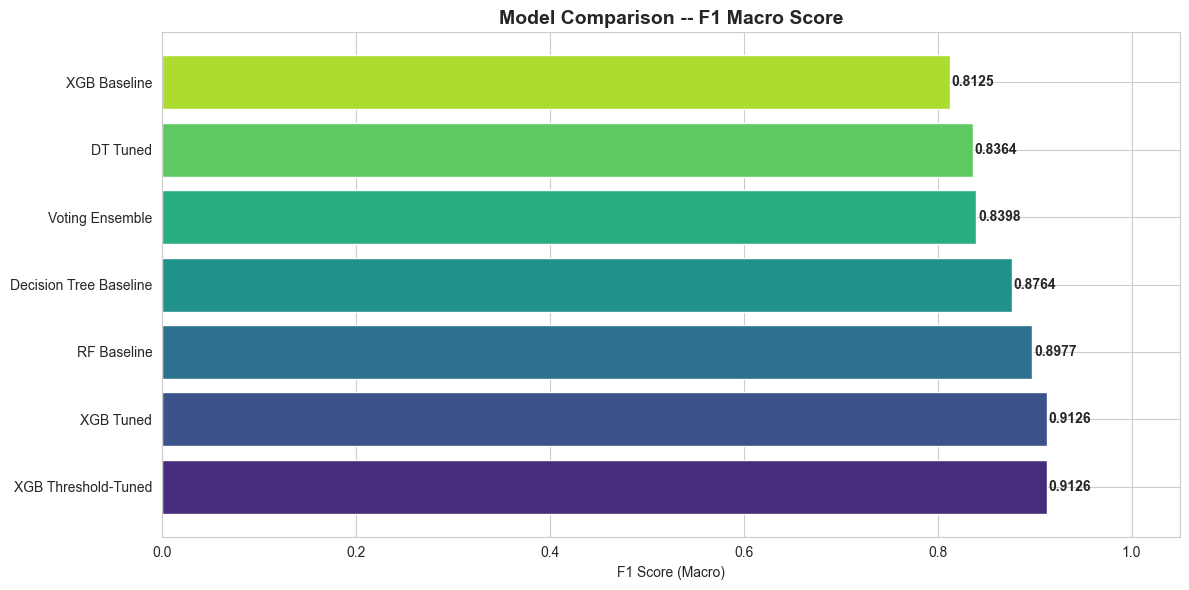

In [37]:
# Plot a horizontal bar chart visualizing the final Macro F1 rankings across all evaluated models.

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(final_df))
bars = ax.barh(range(len(final_df)), final_df['F1(macro)'], color=colors)
ax.set_yticks(range(len(final_df)))
ax.set_yticklabels(final_df.index)
ax.set_xlabel('F1 Score (Macro)')
ax.set_title('Model Comparison -- F1 Macro Score', fontweight='bold', fontsize=14)
for i, v in enumerate(final_df['F1(macro)']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

### Save Best Model


In [48]:
# Save XGB Tuned and XGB Threshold-Tuned artifacts explicitly.
# This version assumes the models were trained on RobustScaler-transformed features.

import pickle
import json

assert 'xgb_tuned' in globals(), 'Run XGB tuned cell first.'
assert 'y_pred_xgb_t' in globals(), 'Run XGB tuned evaluation first.'
assert 'y_pred_thresh' in globals(), 'Run threshold-tuned evaluation first.'
assert 'best_thresh' in globals(), 'Run threshold tuning first.'
assert 'final_df' in globals(), 'Run final ranking cell first.'
assert 'scaler' in globals(), 'Run RobustScaler cell first.'

feature_set = top_features if 'top_features' in globals() else model_features

assert len(feature_set) > 0, 'No model features found.'
assert len(best_thresh) == num_classes, 'Threshold vector length does not match number of classes.'

xgb_tuned_pred_class_8 = np.array([reverse_map[int(p)] for p in y_pred_xgb_t], dtype=int)
xgb_thresh_pred_class_8 = np.array([reverse_map[int(p)] for p in y_pred_thresh], dtype=int)
y_test_class_8 = y_test_atk.to_numpy(dtype=int)

xgb_tuned_path = models_dir / 'multiclass_xgb_tuned.pkl'
xgb_threshold_path = models_dir / 'multiclass_xgb_threshold_tuned.pkl'
xgb_json_path = models_dir / 'multiclass_xgb_tuned.json'
scaler_path = models_dir / 'multiclass_robust_scaler.pkl'
pred_path = results_dir / 'multiclass_xgb_test_predictions.npz'
protocol_path = results_dir / 'multiclass_xgb_protocol.json'
reports_path = results_dir / 'multiclass_xgb_classification_reports.json'

common_package = {
    'scaler': scaler,
    'feature_columns': feature_columns,
    'model_features': feature_set,
    'feature_count': len(feature_set),
    'feature_selection_used': 'top_features' in globals(),
    'model_input_scaled': True,
    'scaler_used': 'RobustScaler',
    'inference_preprocessing': 'select model_features in order, apply saved RobustScaler, then predict',
    'label_map': label_map,
    'reverse_map': reverse_map,
    'attack_names': attack_names,
    'orig_class_8_ids': orig_classes,
    'benign_id': benign_id,
    'num_classes': num_classes,
    'results': results,
    'final_ranking': final_df.to_dict(),
    'boost_factor': BOOST_FACTOR,
    'minority_classes': minority_classes,
    'custom_class_weight': custom_cw,
    'xgb_best_params': study_xgb.best_params,
}

with open(xgb_tuned_path, 'wb') as f:
    pickle.dump({
        **common_package,
        'model': xgb_tuned,
        'model_name': 'XGB Tuned',
        'classification_report': classification_reports.get('XGB Tuned'),
        'thresholds': np.ones(num_classes),
        'threshold_tuned': False,
    }, f)

with open(xgb_threshold_path, 'wb') as f:
    pickle.dump({
        **common_package,
        'model': xgb_tuned,
        'model_name': 'XGB Threshold-Tuned',
        'classification_report': classification_reports.get('XGB Threshold-Tuned'),
        'thresholds': best_thresh,
        'threshold_tuned': True,
    }, f)

xgb_tuned.save_model(str(xgb_json_path))

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

np.savez(
    pred_path,
    y_true_attack_0_6=y_test_enc.to_numpy(dtype=int),
    y_pred_xgb_tuned_attack_0_6=y_pred_xgb_t.astype(int),
    y_pred_xgb_threshold_attack_0_6=y_pred_thresh.astype(int),
    y_true_class_8=y_test_class_8,
    y_pred_xgb_tuned_class_8=xgb_tuned_pred_class_8,
    y_pred_xgb_threshold_class_8=xgb_thresh_pred_class_8,
    test_attack_index=test_attack_index,
    thresholds=best_thresh,
)

protocol = {
    'stage': 'multiclass_7_attack_families',
    'processed_dir': str(processed_dir),
    'feature_order_locked': True,
    'feature_columns': feature_columns,
    'model_features': feature_set,
    'feature_count': len(feature_set),
    'feature_selection_used': 'top_features' in globals(),
    'model_input_scaled': True,
    'scaler_used': 'RobustScaler',
    'inference_preprocessing': 'select model_features in order, apply saved RobustScaler, then predict',
    'benign_id': benign_id,
    'label_map_class_8_to_attack_0_6': {str(k): int(v) for k, v in label_map.items()},
    'reverse_map_attack_0_6_to_class_8': {str(k): int(v) for k, v in reverse_map.items()},
    'attack_names': attack_names,
    'minority_attack_names': minority_attack_names,
    'minority_classes': minority_classes,
    'random_state': RANDOM_STATE,
    'n_trials_per_tuned_model': N_TRIALS,
    'cv_folds': cv.get_n_splits(),
    'xgb_tuned_model_path': str(xgb_tuned_path),
    'xgb_threshold_model_path': str(xgb_threshold_path),
    'xgb_native_model_path': str(xgb_json_path),
    'scaler_path': str(scaler_path),
    'predictions_path': str(pred_path),
    'thresholds': best_thresh.tolist(),
}

with open(protocol_path, 'w', encoding='utf-8') as f:
    json.dump(protocol, f, indent=2)

xgb_reports = {
    'XGB Tuned': classification_reports.get('XGB Tuned'),
    'XGB Threshold-Tuned': classification_reports.get('XGB Threshold-Tuned')
}

with open(reports_path, 'w', encoding='utf-8') as f:
    json.dump(xgb_reports, f, indent=2)

print('XGBoost artifacts saved successfully:')
print(f'  XGB Tuned package:           {xgb_tuned_path}')
print(f'  XGB Threshold-Tuned package: {xgb_threshold_path}')
print(f'  Native XGBoost model:        {xgb_json_path}')
print(f'  RobustScaler:                {scaler_path}')
print(f'  Test predictions:            {pred_path}')
print(f'  Protocol:                    {protocol_path}')
print(f'  Classification reports:      {reports_path}')

XGBoost artifacts saved successfully:
  XGB Tuned package:           D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\models\reviewer3_multiclass\multiclass_xgb_tuned.pkl
  XGB Threshold-Tuned package: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\models\reviewer3_multiclass\multiclass_xgb_threshold_tuned.pkl
  Native XGBoost model:        D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\models\reviewer3_multiclass\multiclass_xgb_tuned.json
  RobustScaler:                D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\models\reviewer3_multiclass\mult